In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("loan_approval_data.csv")

In [4]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

# handling missing values

In [5]:
catagorical_cols=df.select_dtypes(include=["object"]).columns
numerical_cols=df.select_dtypes(include=["number"]).columns

In [6]:
from sklearn.impute import SimpleImputer

In [7]:
num_imp=SimpleImputer(strategy="mean")
df[numerical_cols]=num_imp.fit_transform(df[numerical_cols])

In [8]:
cat_imp=SimpleImputer(strategy="most_frequent")
df[catagorical_cols]=cat_imp.fit_transform(df[catagorical_cols])

In [9]:
df.head()


,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


# Expository data analysis EDA

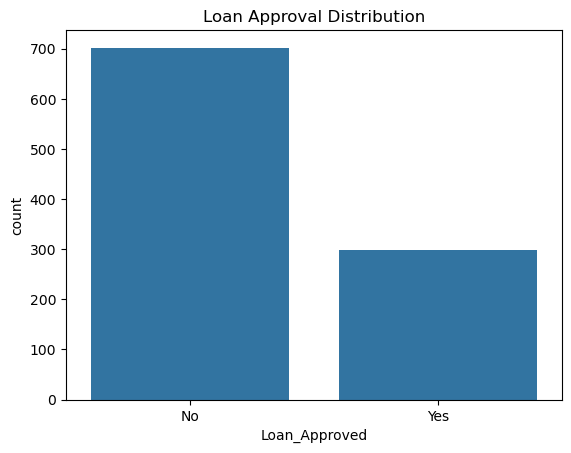

<Figure size 640x480 with 0 Axes>

In [10]:
sns.countplot(x=df["Loan_Approved"])
plt.title("Loan Approval Distribution")
plt.show()
plt.savefig("Loan Approval Distribution.png")

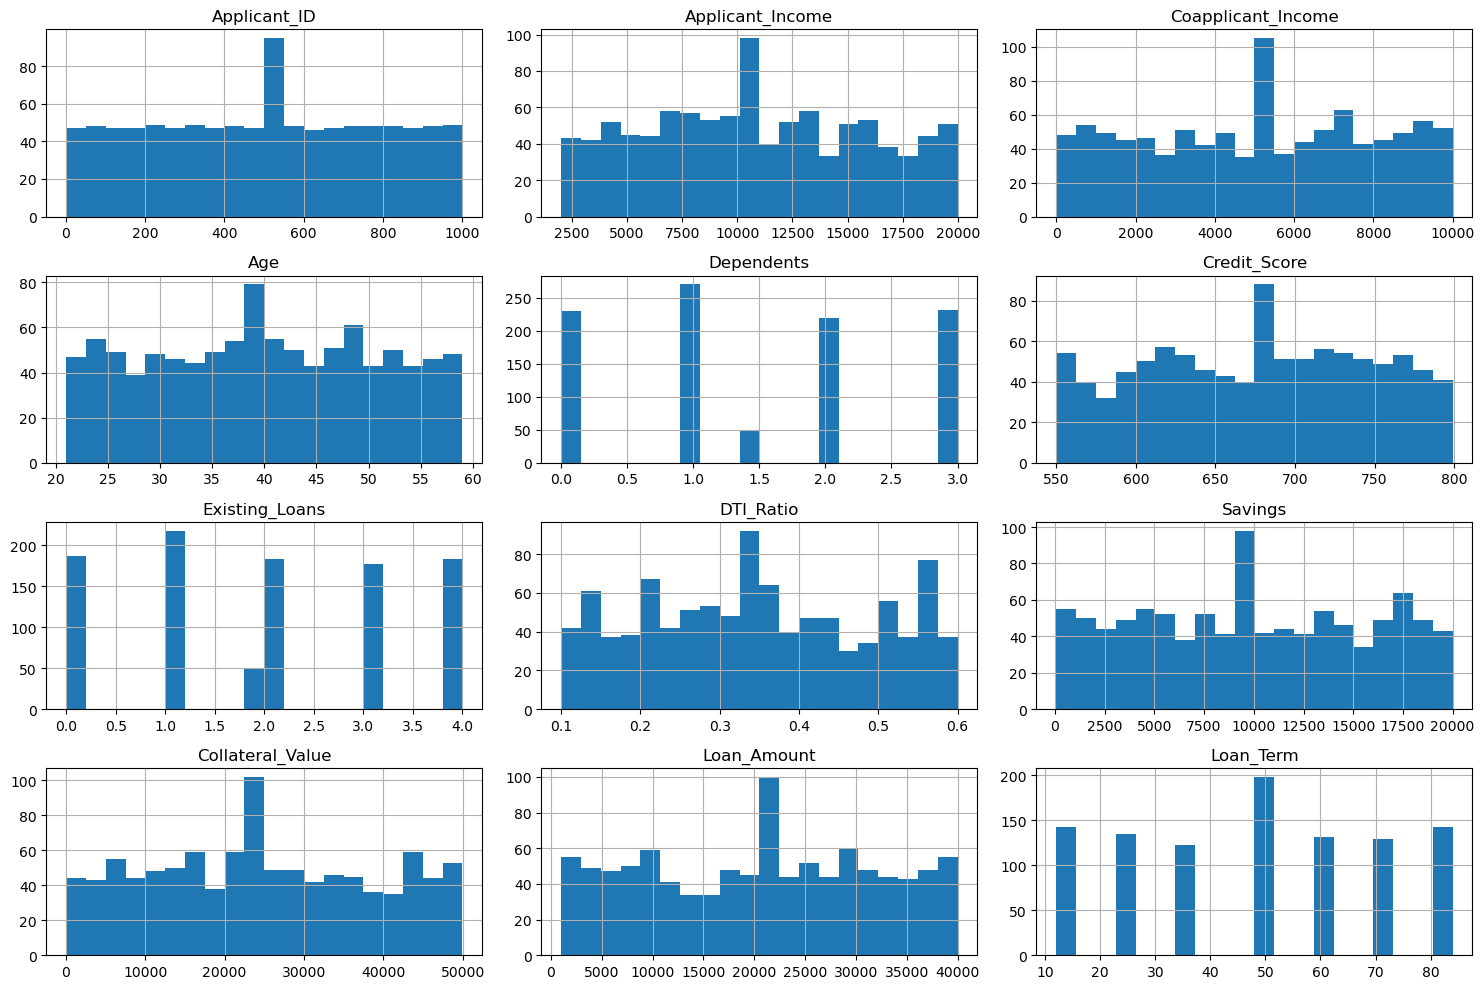

<Figure size 640x480 with 0 Axes>

In [11]:
df[numerical_cols].hist(
    figsize=(15,10),
    bins=20
)
plt.tight_layout()
plt.show()
plt.savefig("Numerical Columns Analysis.png")

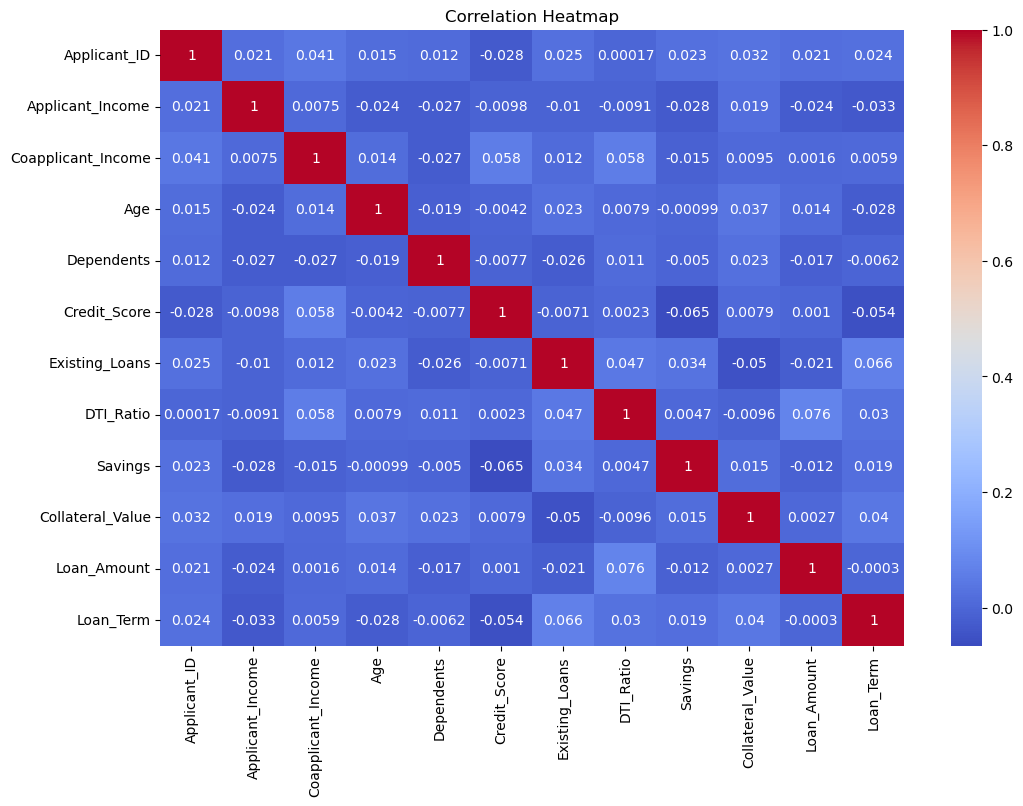

<Figure size 640x480 with 0 Axes>

In [12]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()
plt.savefig("Correlation Heatmap.png")

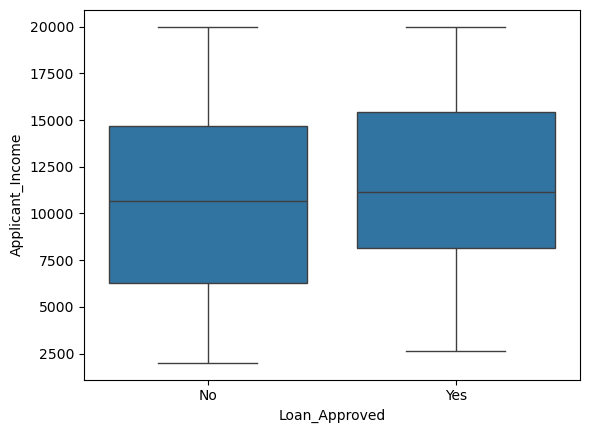

<Figure size 640x480 with 0 Axes>

In [13]:
sns.boxplot(
    x=df["Loan_Approved"],
    y=df["Applicant_Income"]
)

plt.show()
plt.savefig("Boxplot.png")

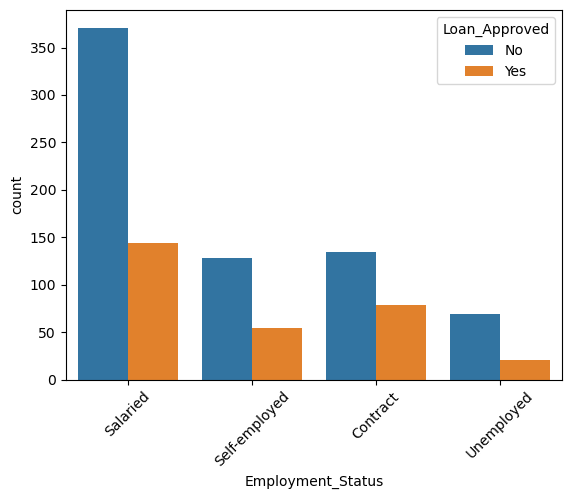

<Figure size 640x480 with 0 Axes>

In [14]:
sns.countplot(
    x="Employment_Status",
    hue="Loan_Approved",
    data=df
)

plt.xticks(rotation=45)
plt.show()
plt.savefig("Target vs catagorical features.png")

In [15]:
pd.crosstab(
    df["Employment_Status"],
    df["Loan_Approved"],
    normalize="index"
)*100
#plt.savefig("loan approval rate by catagory.png")

Loan_Approved,No,Yes
Employment_Status,,
Contract,62.910798,37.089202
Salaried,72.038835,27.961165
Self-employed,70.329670,29.670330
Unemployed,76.666667,23.333333


# Encoding

In [16]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [17]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        1000 non-null   float64
 1   Applicant_Income    1000 non-null   float64
 2   Coapplicant_Income  1000 non-null   float64
 3   Employment_Status   1000 non-null   object 
 4   Age                 1000 non-null   float64
 5   Marital_Status      1000 non-null   object 
 6   Dependents          1000 non-null   float64
 7   Credit_Score        1000 non-null   float64
 8   Existing_Loans      1000 non-null   float64
 9   DTI_Ratio           1000 non-null   float64
 10  Savings             1000 non-null   float64
 11  Collateral_Value    1000 non-null   float64
 12  Loan_Amount         1000 non-null   float64
 13  Loan_Term           1000 non-null   float64
 14  Loan_Purpose        1000 non-null   object 
 15  Property_Area       1000 non-null   object 
 16  Educati

In [18]:
le=LabelEncoder()
df["Education_Level"]=le.fit_transform(df["Education_Level"])
df["Loan_Approved"]=le.fit_transform(df["Loan_Approved"])
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [19]:
cols=["Employment_Status","Loan_Purpose", "Marital_Status","Property_Area",
      "Gender","Employer_Category"]

In [37]:
ohe = OneHotEncoder(handle_unknown='ignore',sparse_output=False)
encoded=ohe.fit_transform(df[cols])
encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cols),index=df.index)


KeyError: "None of [Index(['Employment_Status', 'Loan_Purpose', 'Marital_Status', 'Property_Area',\n       'Gender', 'Employer_Category'],\n      dtype='object')] are in the [columns]"

In [21]:
encoded_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Employment_Status_Contract       1000 non-null   float64
 1   Employment_Status_Salaried       1000 non-null   float64
 2   Employment_Status_Self-employed  1000 non-null   float64
 3   Employment_Status_Unemployed     1000 non-null   float64
 4   Loan_Purpose_Business            1000 non-null   float64
 5   Loan_Purpose_Car                 1000 non-null   float64
 6   Loan_Purpose_Education           1000 non-null   float64
 7   Loan_Purpose_Home                1000 non-null   float64
 8   Loan_Purpose_Personal            1000 non-null   float64
 9   Marital_Status_Married           1000 non-null   float64
 10  Marital_Status_Single            1000 non-null   float64
 11  Property_Area_Rural              1000 non-null   float64
 12  Property_Area_Semiurb

In [22]:
df=pd.concat([df.drop(columns=cols),encoded_df],axis=1)

In [23]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 35 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_ID                     1000 non-null   float64
 1   Applicant_Income                 1000 non-null   float64
 2   Coapplicant_Income               1000 non-null   float64
 3   Age                              1000 non-null   float64
 4   Dependents                       1000 non-null   float64
 5   Credit_Score                     1000 non-null   float64
 6   Existing_Loans                   1000 non-null   float64
 7   DTI_Ratio                        1000 non-null   float64
 8   Savings                          1000 non-null   float64
 9   Collateral_Value                 1000 non-null   float64
 10  Loan_Amount                      1000 non-null   float64
 11  Loan_Term                        1000 non-null   float64
 12  Education_Level      

# Corelation heatmap

<Axes: >

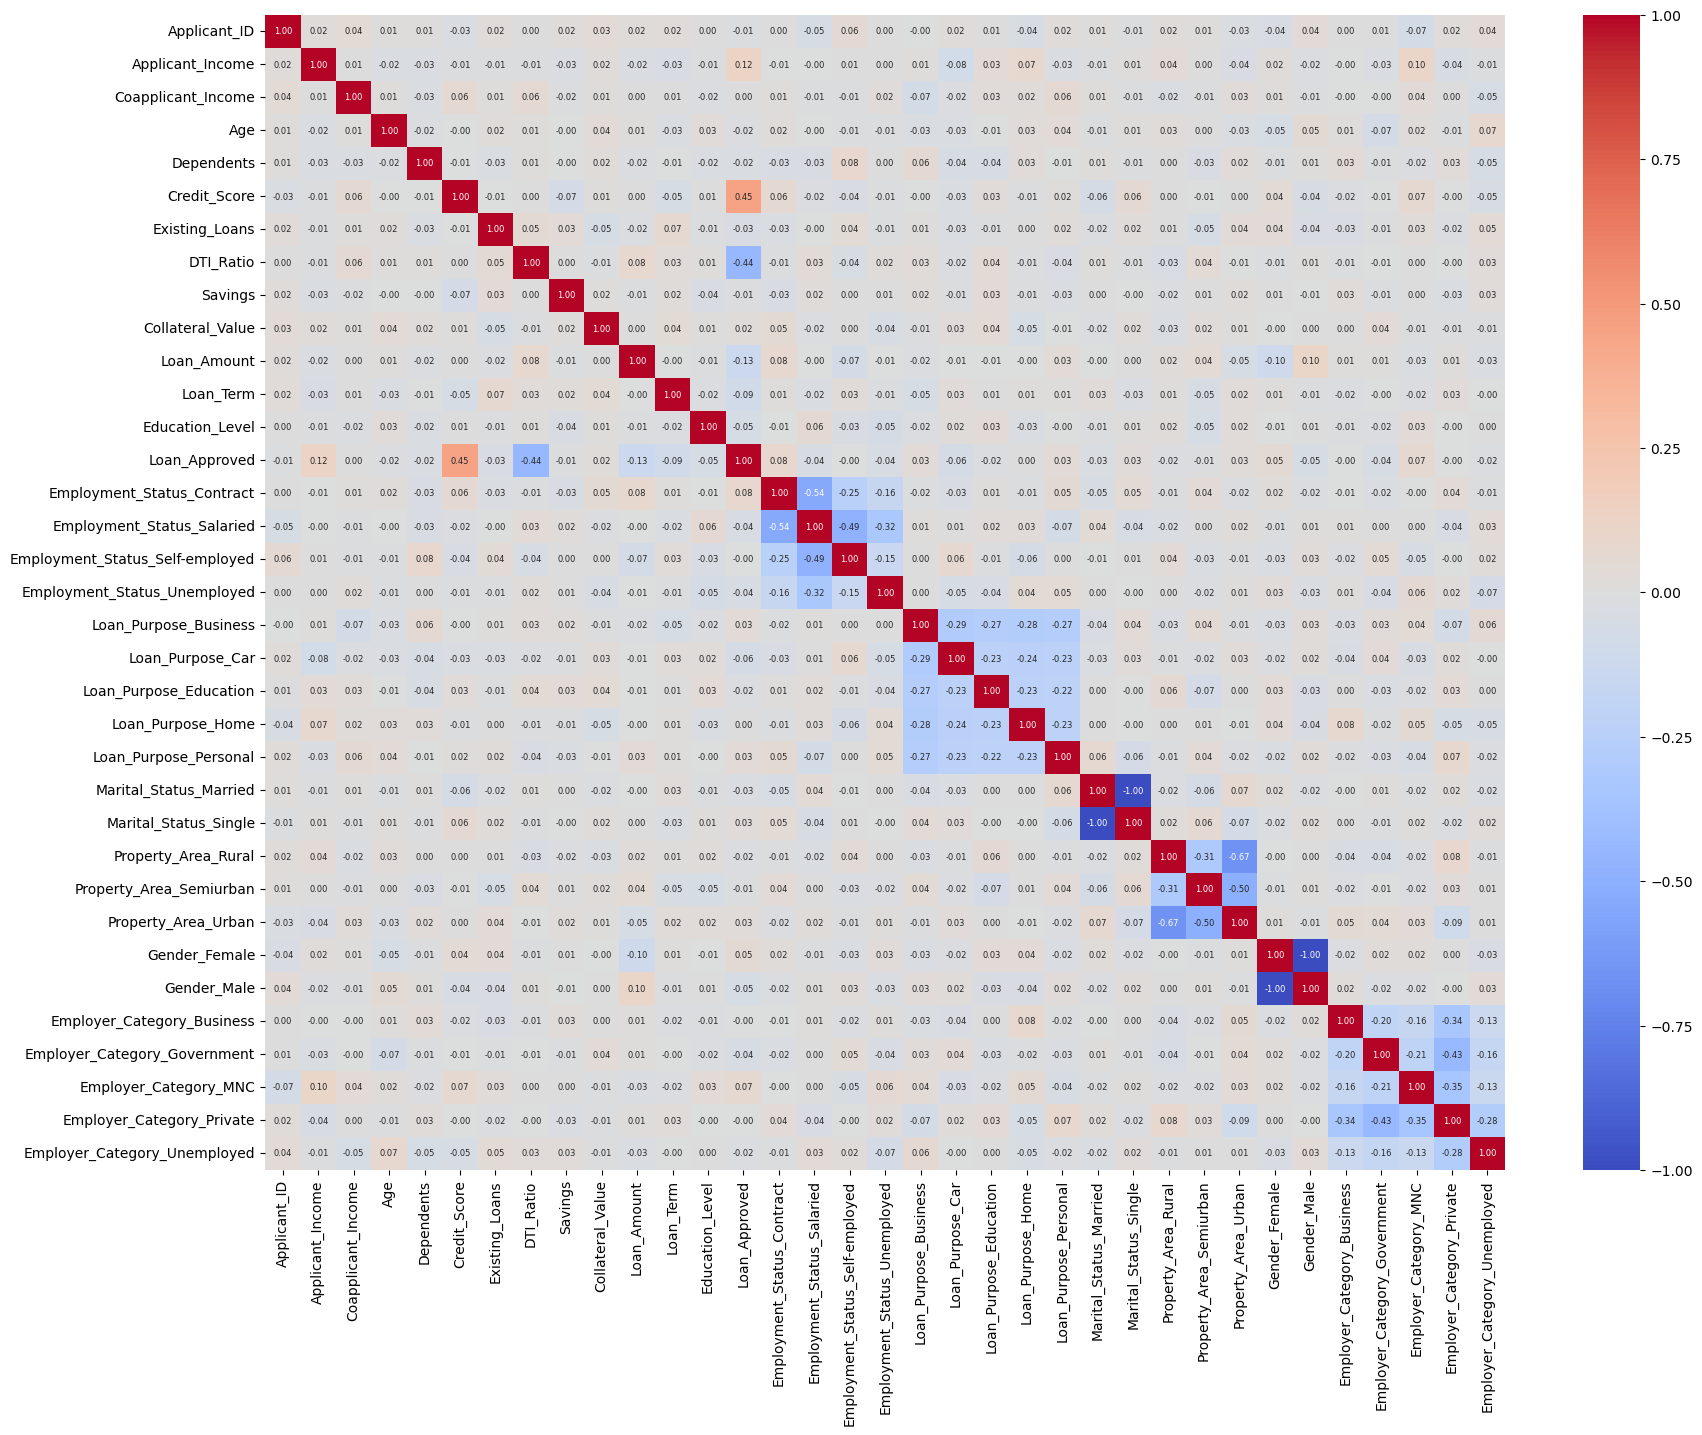

In [34]:
num_cols=df.select_dtypes(include="number")
corr_matrix=num_cols.corr()


plt.figure(figsize=(20,15))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    annot_kws={"size":6},
    cmap="coolwarm"
)

In [27]:
num_cols.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employment_Status_Contract         0.082910
Employer_Category_MNC              0.069049
Gender_Female                      0.054342
Loan_Purpose_Business              0.034767
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Business        -0.001472
Employer_Category_Private         -0.003347
Applicant_ID                      -0.011167
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Property_Area_Rural               -0.017334
Employer_Category_Unemployed      -0.021468
Age                             

# Train Test Split and Feature Scaling

In [39]:
x=df.drop("Loan_Approved",axis=1)
y=df["Loan_Approved"]

In [41]:
x.head()
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Loan_Approved, dtype: int64

In [44]:
# Train Test Split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [45]:
x_test.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban,Gender_Female,Gender_Male,Employer_Category_Business,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
521,522.0,13023.0,6675.0,53.000000,3.0,628.0,3.0,0.347263,10051.000000,26309.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
737,738.0,15917.0,6787.0,42.000000,0.0,588.0,4.0,0.410000,922.000000,13476.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
740,741.0,7560.0,3530.0,52.000000,3.0,606.0,0.0,0.580000,9940.452632,21795.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
660,661.0,19022.0,574.0,59.000000,0.0,725.0,4.0,0.410000,1463.000000,44498.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
411,412.0,4967.0,5797.0,39.971579,3.0,697.0,4.0,0.580000,1095.000000,3017.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


In [47]:
#Standard scaler 
from sklearn.preprocessing import StandardScaler

In [49]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

# Train And Evaluate Models

In [51]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train_scaled,y_train)
y_pred=model.predict(x_test_scaled)

In [55]:
from sklearn.metrics import confusion_matrix ,precision_score,accuracy_score,recall_score,f1_score

In [59]:
print("----Logistic Regression Model----")
print("Presion:",precision_score(y_test,y_pred))
print("accuracy_score:",accuracy_score(y_test,y_pred))
print("recall_score:",recall_score(y_test,y_pred))
print("f1_score:",f1_score(y_test,y_pred))
print("confusion_matrix:",confusion_matrix(y_test,y_pred))


----Logistic Regression Model----
Presion: 0.7868852459016393
accuracy_score: 0.87
recall_score: 0.7868852459016393
f1_score: 0.7868852459016393
confusion_matrix: [[126  13]
 [ 13  48]]


# KNN Classifier

In [64]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=13)

model.fit(x_train_scaled,y_train)
y_pred=model.predict(x_test_scaled)
 

In [65]:
print("----KNN Classifier Model----")
print("Presion:",precision_score(y_test,y_pred))
print("accuracy_score:",accuracy_score(y_test,y_pred))
print("recall_score:",recall_score(y_test,y_pred))
print("f1_score:",f1_score(y_test,y_pred))
print("confusion_matrix:",confusion_matrix(y_test,y_pred))

----KNN Classifier Model----
Presion: 0.5945945945945946
accuracy_score: 0.73
recall_score: 0.36065573770491804
f1_score: 0.4489795918367347
confusion_matrix: [[124  15]
 [ 39  22]]


# Naive Bayes Model

In [68]:
from sklearn.naive_bayes import GaussianNB

In [69]:
model=GaussianNB()
model.fit(x_train_scaled,y_train)
y_pred=model.predict(x_test_scaled)

In [70]:
print("----Naive Bayes Model----")
print("Presion:",precision_score(y_test,y_pred))
print("accuracy_score:",accuracy_score(y_test,y_pred))
print("recall_score:",recall_score(y_test,y_pred))
print("f1_score:",f1_score(y_test,y_pred))
print("confusion_matrix:",confusion_matrix(y_test,y_pred))

----Naive Bayes Model----
Presion: 0.7758620689655172
accuracy_score: 0.855
recall_score: 0.7377049180327869
f1_score: 0.7563025210084033
confusion_matrix: [[126  13]
 [ 16  45]]


# Doing Feature Engneering

In [74]:
df["DTI_Ratio_sq"]=df["DTI_Ratio"]**2
df["Credit_Score_sq"]=df["Credit_Score"]**2

x = df.drop(columns=["Loan_Approved","DTI_Ratio","Credit_Score"])
y = df["Loan_Approved"]

#train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)



# Models after feature Engeneering

In [75]:
# Logistic Regression
model=LogisticRegression()
model.fit(x_train_scaled,y_train)
y_pred=model.predict(x_test_scaled)

print("----Logistic Regression Model----")
print("Presion:",precision_score(y_test,y_pred))
print("accuracy_score:",accuracy_score(y_test,y_pred))
print("recall_score:",recall_score(y_test,y_pred))
print("f1_score:",f1_score(y_test,y_pred))
print("confusion_matrix:",confusion_matrix(y_test,y_pred))

----Logistic Regression Model----
Presion: 0.7903225806451613
accuracy_score: 0.875
recall_score: 0.8032786885245902
f1_score: 0.7967479674796748
confusion_matrix: [[126  13]
 [ 12  49]]


In [76]:
# Knn classifier
model=KNeighborsClassifier(n_neighbors=13)

model.fit(x_train_scaled,y_train)
y_pred=model.predict(x_test_scaled)

print("----KNN Classifier Model----")
print("Presion:",precision_score(y_test,y_pred))
print("accuracy_score:",accuracy_score(y_test,y_pred))
print("recall_score:",recall_score(y_test,y_pred))
print("f1_score:",f1_score(y_test,y_pred))
print("confusion_matrix:",confusion_matrix(y_test,y_pred))

----KNN Classifier Model----
Presion: 0.6666666666666666
accuracy_score: 0.75
recall_score: 0.36065573770491804
f1_score: 0.46808510638297873
confusion_matrix: [[128  11]
 [ 39  22]]


In [77]:
# Naive Bayes
model=GaussianNB()
model.fit(x_train_scaled,y_train)
y_pred=model.predict(x_test_scaled)

print("----Naive Bayes Model----")
print("Presion:",precision_score(y_test,y_pred))
print("accuracy_score:",accuracy_score(y_test,y_pred))
print("recall_score:",recall_score(y_test,y_pred))
print("f1_score:",f1_score(y_test,y_pred))
print("confusion_matrix:",confusion_matrix(y_test,y_pred))


----Naive Bayes Model----
Presion: 0.7833333333333333
accuracy_score: 0.865
recall_score: 0.7704918032786885
f1_score: 0.7768595041322314
confusion_matrix: [[126  13]
 [ 14  47]]


# After doing feature engneering Logistic Regression Model is best Model because its Precission and Recall is good as required.